<a href="https://colab.research.google.com/github/tthuy123/graduation/blob/main/MODEL_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import pandas as pd

from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

2026-04-14 06:30:51.051640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776148251.289491      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776148251.360234      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776148251.910684      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776148251.910743      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776148251.910747      16 computation_placer.cc:177] computation placer alr

In [2]:
# =====================================================
# CONFIG
# =====================================================

@dataclass
class Config:
    data_dir: str = "/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad"
    max_weeks: int = 40
    test_size: float = 0.2
    random_state: int = 42
    learning_rate: float = 1e-3
    batch_size: int = 64
    epochs: int = 25


CFG = Config()

# EARLY_MARKERS = [0.1,0.2, 0.4, 0.6, 0.8, 1.0]
EARLY_MARKERS = [0.2]

In [3]:
# =====================================================
# SEED
# =====================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [4]:
# =====================================================
# UTIL
# =====================================================

def map_day_to_week(day, max_weeks):
    if pd.isna(day) or day < 0:
        return 0
    week = int(day // 7)
    return min(week, max_weeks - 1)

In [5]:
# =====================================================
# LOAD DATA
# =====================================================

def load_data(data_dir):

    files = {
        "student_info": "studentInfo.csv",
        "student_vle": "studentVle.csv",
        "student_assessment": "studentAssessment.csv",
        "assessment": "assessments.csv",
        "vle": "vle.csv"
    }

    data = {}

    for k, v in files.items():
        path = os.path.join(data_dir, v)
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        data[k] = pd.read_csv(path)

    return data

In [6]:
# =====================================================
# TARGET
# =====================================================

def build_target(df):

    df = df.copy()

    df["target"] = df["final_result"].apply(
        lambda x: 1 if x in ["Pass", "Distinction"] else 0
    )

    return df

In [7]:
# =====================================================
# CLICK SERIES
# =====================================================

def build_click_series(df_student_vle, cutoff_week):

    df = df_student_vle.copy()

    df["week_idx"] = df["date"].apply(
        lambda x: map_day_to_week(x, CFG.max_weeks)
    )

    df = df[df["week_idx"] < cutoff_week]

    grouped = df.groupby(
        ["id_student", "code_module", "code_presentation", "week_idx"]
    )["sum_click"].sum().reset_index()

    pivot = grouped.pivot_table(
        index=["id_student", "code_module", "code_presentation"],
        columns="week_idx",
        values="sum_click",
        fill_value=0
    )

    pivot = pivot.reindex(columns=list(range(cutoff_week)), fill_value=0)

    pivot.columns = [f"click_wk_{i}" for i in pivot.columns]

    return pivot.reset_index()

In [8]:
# =====================================================
# ACTIVITY FEATURES
# =====================================================

def build_activity_features(student_vle, vle, cutoff_week):

    df = student_vle.merge(
        vle[["id_site", "activity_type"]],
        on="id_site",
        how="left"
    )

    df["week_idx"] = df["date"].apply(
        lambda x: map_day_to_week(x, CFG.max_weeks)
    )

    df = df[df["week_idx"] < cutoff_week]

    activity_types = vle["activity_type"].unique().tolist()

    activity = df.pivot_table(
        index=["id_student","code_module","code_presentation","week_idx"],
        columns="activity_type",
        values="sum_click",
        aggfunc="sum",
        fill_value=0
    ).reset_index()

    for col in activity_types:
        if col not in activity.columns:
            activity[col] = 0

    activity["total"] = activity[activity_types].sum(axis=1)
    activity["inactive"] = (activity["total"] == 0).astype(int)
    activity["total"] = activity["total"].replace(0, 1)

    for col in activity_types:
        activity[f"{col}_ratio"] = activity[col] / activity["total"]

    def entropy(row):
        vals = row[activity_types].values.astype(float)
        total = vals.sum()
        if total == 0:
            return 0
        p = vals / total
        p = p[p > 0]
        return -(p * np.log(p)).sum()

    activity["entropy"] = activity.apply(entropy, axis=1)

    feature_cols = [f"{c}_ratio" for c in activity_types] + ["entropy", "inactive"]

    pivot = activity.pivot_table(
        index=["id_student","code_module","code_presentation"],
        columns="week_idx",
        values=feature_cols,
        fill_value=0
    )

    full_cols = pd.MultiIndex.from_product(
        [feature_cols, range(cutoff_week)]
    )

    pivot = pivot.reindex(columns=full_cols, fill_value=0)

    pivot.columns = [
        f"{feat}_wk_{week}" for feat, week in pivot.columns
    ]

    return pivot.reset_index()

In [9]:
def build_assessment_series(df_student_assessment, df_assessment, max_weeks, cutoff_week):
    """
    Args:
        df_student_assessment: Bảng kết quả nộp bài của sinh viên.
        df_assessment: Bảng thông tin các bài kiểm tra (có cột 'date' là hạn chót).
        max_weeks: Tổng số tuần tối đa của khóa học.
        cutoff_week: Tuần hiện tại
    """

    # 1. Kết hợp dữ liệu
    merged = df_student_assessment.merge(df_assessment, on="id_assessment")

    # 2. XÁC ĐỊNH TUẦN
    merged["date"] = merged["date"].fillna(0)
    merged["week_idx"] = (merged["date"] // 7).astype(int)

    # 3. CHẶN DỮ LIỆU TƯƠNG LAI
    merged = merged[merged["week_idx"] < cutoff_week].copy()

    # 4. LATENESS
    def calc_lateness(row):
        if pd.isna(row["date_submitted"]):
            cutoff_day = cutoff_week * 7
            return max(0, cutoff_day - row["date"])
        else:
            return row["date_submitted"] - row["date"]

    merged["lateness"] = merged.apply(calc_lateness, axis=1)
    merged["score"] = merged["score"].fillna(0)
    merged["weight"] = merged["weight"].fillna(0)

    merged["has_assessment"] = 1  # nếu record tồn tại thì chắc chắn có bài
    
    # 5. PIVOT
    idx = ["id_student", "code_module", "code_presentation"]
    target_weeks = list(range(cutoff_week))

    # Score
    score_pivot = merged.pivot_table(
        index=idx, columns="week_idx", values="score", aggfunc="mean"
    ).reindex(columns=target_weeks)

    # Lateness
    late_pivot = merged.pivot_table(
        index=idx, columns="week_idx", values="lateness", aggfunc="mean"
    ).reindex(columns=target_weeks, fill_value=0)

    # Weight
    weight_pivot = merged.pivot_table(
        index=idx, columns="week_idx", values="weight", aggfunc="max"
    ).reindex(columns=target_weeks, fill_value=0)

    has_assessment_pivot = merged.pivot_table(
        index=idx, columns="week_idx", values="has_assessment", aggfunc="max"
    ).reindex(columns=target_weeks, fill_value=0)

    # 6. RENAME
    score_pivot.columns = [f"score_wk_{i}" for i in score_pivot.columns]
    late_pivot.columns = [f"late_wk_{i}" for i in late_pivot.columns]
    weight_pivot.columns = [f"weight_wk_{i}" for i in weight_pivot.columns]
    has_assessment_pivot.columns = [f"has_assessment_wk_{i}" for i in has_assessment_pivot.columns]

    # 7. MERGE
    df_final = (
        score_pivot
        .join(late_pivot)
        .join(weight_pivot)
        .join(has_assessment_pivot)
        .reset_index()
    )

    return df_final

In [10]:
def build_dataset(data, cutoff_week):
    df_info = build_target(data["student_info"])

    df_click = build_click_series(
        data["student_vle"],
        cutoff_week
    )

    df_assess = build_assessment_series(
        data["student_assessment"],
        data["assessment"],
        CFG.max_weeks,
        cutoff_week
    )

    df_activity = build_activity_features(
        data["student_vle"],
        data["vle"],
        cutoff_week
    )

    keys = ["id_student", "code_module", "code_presentation"]

    df = df_info.merge(df_click, on=keys, how="left")
    df = df.merge(df_assess, on=keys, how="left")
    df = df.merge(df_activity, on=keys, how="left")

    # df = df.fillna(0)

    return df

In [11]:
def prepare_features_df(df, activity_types, cutoff_week):

    df = df.copy()

    y = df["target"].astype(int)
    df_ids = df[["id_student"]].copy()

    df = df.drop(columns=[
        "target",
        "final_result",
        "id_student",
        "code_module",
        "code_presentation"
    ], errors="ignore")

    # =============================
    # REMOVE FUTURE FEATURES
    # =============================
    safe_cols = []
    for col in df.columns:
        if "_wk_" in col:
            week = int(col.split("_wk_")[-1])
            if week < cutoff_week:
                safe_cols.append(col)
        else:
            safe_cols.append(col)

    df = df[safe_cols]

    # =============================
    # ONE HOT
    # =============================
    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

    df.columns = (
        df.columns
        .astype(str)
        .str.replace(r"[<>\[\]]", "_", regex=True)
        .str.replace(r"\s+", "_", regex=True)
    )

    X_df = df.astype(np.float32)

    return X_df, y, df_ids

## SHAP MODULE

In [12]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def get_explanation_indices(y_true, y_pred):
    """Tìm index cho 4 trường hợp Local Explanation"""
    indices = {}
    # 1. Đỗ - Đoán đúng (True Positive)
    tp = np.where((y_true == 1) & (y_pred == 1))[0]
    indices['Pass_Correct'] = tp[0] if len(tp) > 0 else None
    
    # 2. Trượt - Đoán đúng (True Negative)
    tn = np.where((y_true == 0) & (y_pred == 0))[0]
    indices['Fail_Correct'] = tn[0] if len(tn) > 0 else None
    
    # 3. Đỗ - Đoán sai (False Negative)
    fn = np.where((y_true == 1) & (y_pred == 0))[0]
    indices['Pass_Incorrect'] = fn[0] if len(fn) > 0 else None
    
    # 4. Trượt - Đoán sai (False Positive)
    fp = np.where((y_true == 0) & (y_pred == 1))[0]
    indices['Fail_Incorrect'] = fp[0] if len(fp) > 0 else None
    
    return indices

In [14]:
def debug_feature_names(X_df):
    bad_cols = [
        col for col in X_df.columns
        if any(c in str(col) for c in ['[', ']', '<'])
        or not isinstance(col, str)
    ]

    print(f"Found {len(bad_cols)} problematic columns:")
    for col in bad_cols[:20]:
        print(col)

    return bad_cols

In [15]:
def run_xgb_clean():

    data = load_data(CFG.data_dir)
    activity_types = data["vle"]["activity_type"].unique().tolist()

    for marker in EARLY_MARKERS:

        print(f"\n===== {marker*100:.0f}% =====")

        cutoff_week = int(CFG.max_weeks * marker)

        df = build_dataset(data, cutoff_week)

        X_df, y, df_ids = prepare_features_df(df, activity_types, cutoff_week)
        debug_feature_names(X_df)

        X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
            X_df, y, df_ids,
            test_size=0.2,
            stratify=y,
            random_state=42
        )

        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )

        model.fit(X_train, y_train)

        # =========================
        # EVALUATE
        # =========================
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        print(classification_report(y_test, y_pred, digits=5))

        # =========================
        # SHAP
        # =========================
        explain_xgb_clean(
            model,
            X_test,
            y_test,
            marker
        )

In [16]:
def explain_xgb_clean(model, X_test, y_test, marker):

    print(f"\n>>> SHAP {marker*100:.0f}%")

    # X_sample = X_test.sample(min(500, len(X_test)), random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)

    # =========================
    # GLOBAL
    # =========================
    shap.plots.beeswarm(shap_values)

    # =========================
    # LOCAL
    # =========================
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    case_indices = get_explanation_indices(y_test, y_pred)
    
    feature_names = X_test.columns.tolist()
    
    for case_name, idx in case_indices.items():
        if idx is not None:
            print(f"Showing Local Explanation for: {case_name}")
    
            shap_exp = shap.Explanation(
                values=shap_values.values[idx],
                base_values=explainer.expected_value,
                data=X_test.iloc[idx].values,
                feature_names=feature_names
            )
    
            shap.plots.waterfall(shap_exp, show=True)

## RUN 


===== 20% =====
Found 0 problematic columns:
              precision    recall  f1-score   support

           0    0.89143   0.80389   0.84540      3442
           1    0.80234   0.89048   0.84412      3077

    accuracy                        0.84476      6519
   macro avg    0.84689   0.84719   0.84476      6519
weighted avg    0.84938   0.84476   0.84479      6519


>>> SHAP 20%


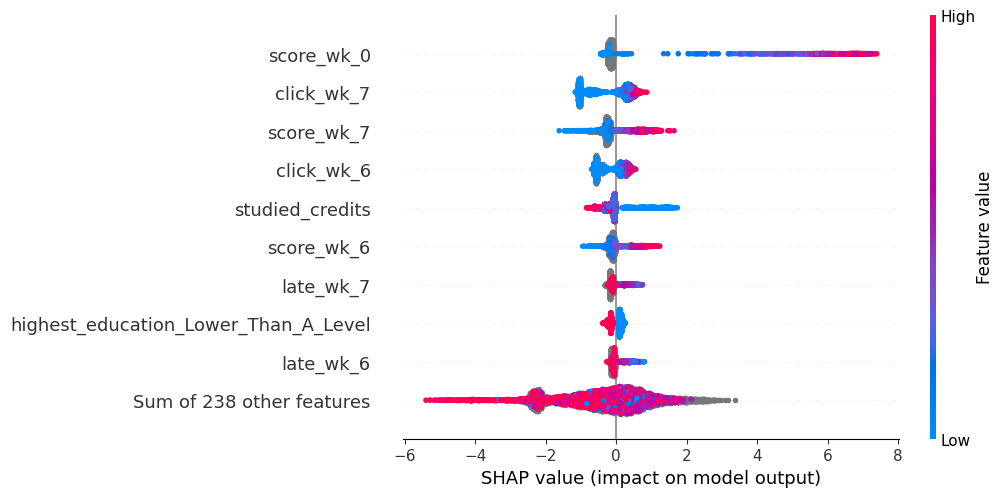

Showing Local Explanation for: Pass_Correct


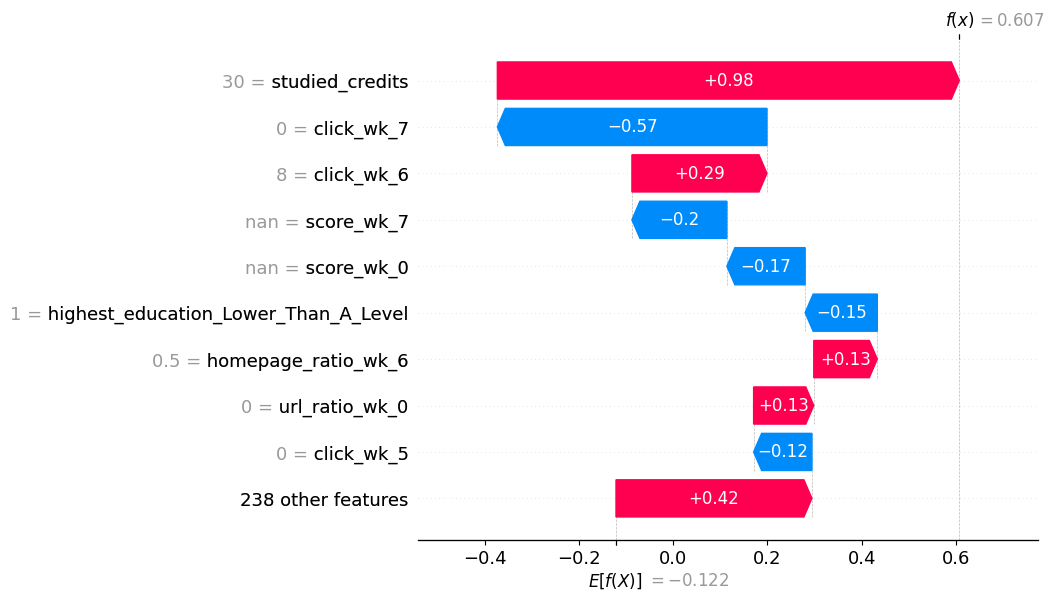

Showing Local Explanation for: Fail_Correct


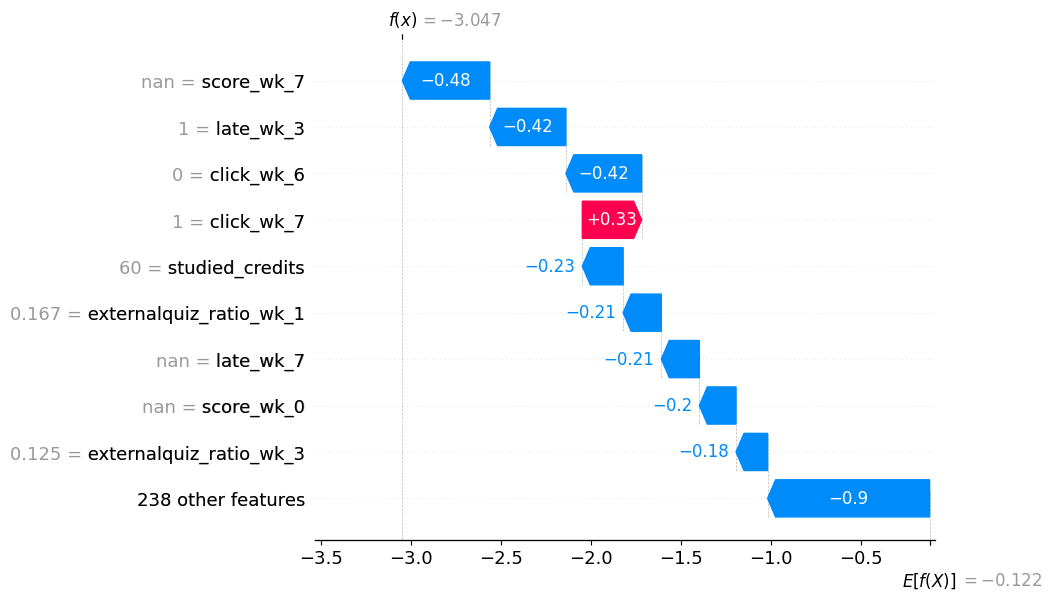

Showing Local Explanation for: Pass_Incorrect


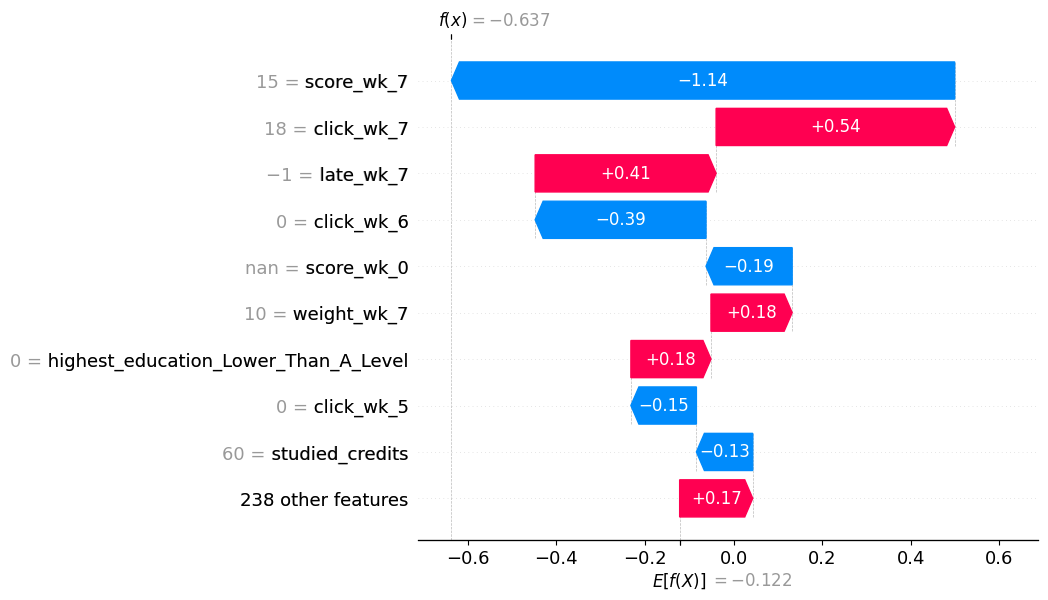

Showing Local Explanation for: Fail_Incorrect


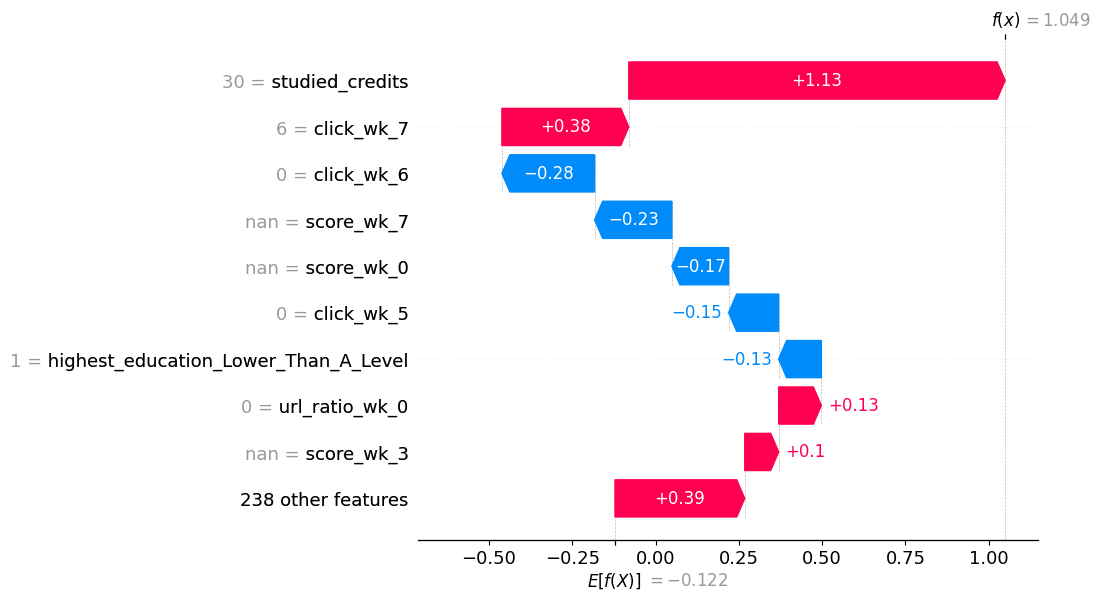

In [17]:
if __name__ == "__main__":
    run_xgb_clean()